In [7]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "kwill580"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()
if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Assignments/Final Exam"
#os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

✅ Already inside repo folder: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design


# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: May 11, 2026

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=10$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

2. State the outcome variable and how it was measured.

3. State the independent variables. What lurking variables may be present?

4. Why might a full factorial design be preferred in this specific instance to a $2^k$ fractional factorial design?

5. State all sets of statistical hypotheses.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.


In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.formula.api import mixedlm
from scipy import stats
from scipy.stats import chi2
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns
#Import Data
burritos = pd.read_excel('/content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam/Busters Burritos.xlsx')

## Data Integrity Check ##

print(burritos.info())

## Exploratory Data Analysis ##
## Start with Main Effects ##

## Protein ##

protein_stats = burritos.groupby("Protein")["Satisfaction"].agg(['mean', 'std'])

print(protein_stats)

## Salsa ##

salsa_stats = burritos.groupby("Salsa")["Satisfaction"].agg(['mean', 'std'])

print(salsa_stats)

## Potatoes ##

potatoes_stats = burritos.groupby("Potatoes")["Satisfaction"].agg(['mean', 'std'])

print(potatoes_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Protein       120 non-null    object 
 1   Salsa         120 non-null    object 
 2   Potatoes      120 non-null    object 
 3   Satisfaction  120 non-null    float64
dtypes: float64(1), object(3)
memory usage: 3.9+ KB
None
           mean       std
Protein                  
Bacon    6.8500  0.928467
Chorizo  7.0075  1.167374
Sausage  5.7725  1.052710
           mean       std
Salsa                    
Hot    6.070000  1.116031
Mild   7.016667  1.055762
              mean       std
Potatoes                    
No        6.335000  1.227071
Yes       6.751667  1.105378


In [9]:
## Question 6 Code ##

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

In [10]:
## Question 7 Code ##

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

In [11]:
## Question 8 Code ##

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

In [12]:
## Question 9 Code ##

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.

In [13]:
## Question 10 Code ##

11. Calculate and interpret partial $\eta^2$ for the main effects.

In [14]:
## Question 11 Code ##

12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=3$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

2. Specify the outcome variable and how it is measured.

3. Specify the independent variables. What lurking variables may be present?

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

5. State the sets of null and alternative hypotheses for this experiment.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

In [17]:
## Import relevant libraries ##
import pandas as pd
import numpy as np

## Read in the Data ##

sales = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam/Busters Burrito Sales.xlsx")

## Evaluate the Data ##

print(sales.info())
print(sales.head())
## Add Effect Column to sales dataframe ##

sales['Effect'] = np.repeat(["c","b","a","abc"], repeats=6)

print(sales.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   24 non-null     object 
 1   Timing     24 non-null     object 
 2   Marketing  24 non-null     object 
 3   Sales      24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 900.0+ bytes
None
     Location   Timing    Marketing   Sales
0     Brewery  Weekday  Independent  800.93
1     Brewery  Weekday  Independent  895.44
2     Brewery  Weekday  Independent  728.44
3  University  Weekday  Independent  739.61
4  University  Weekday  Independent  804.20
     Location   Timing    Marketing   Sales Effect
0     Brewery  Weekday  Independent  800.93      c
1     Brewery  Weekday  Independent  895.44      c
2     Brewery  Weekday  Independent  728.44      c
3  University  Weekday  Independent  739.61      c
4  University  Weekday  Independent  804.20      c


     Location         mean         std
0     Brewery  1130.844167  240.497137
1  University   969.116667  226.779048
    Timing         mean         std
0  Weekday   856.971667  139.886119
1  Weekend  1242.989167  150.626558
     Marketing         mean         std
0  Independent   956.325833  213.917393
1  Partnership  1143.635000  242.150011


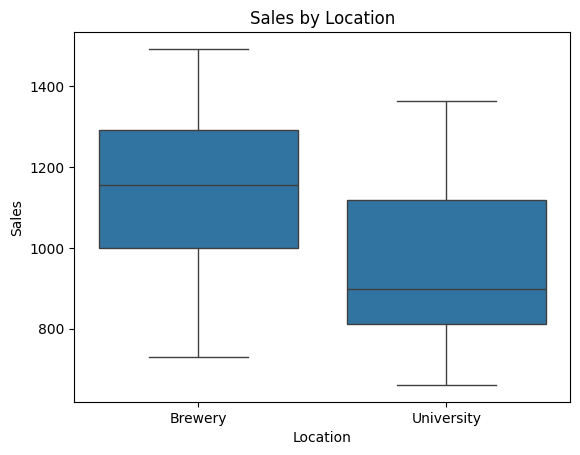

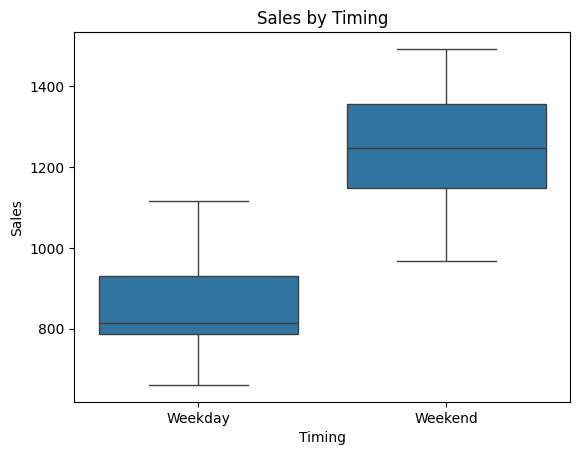

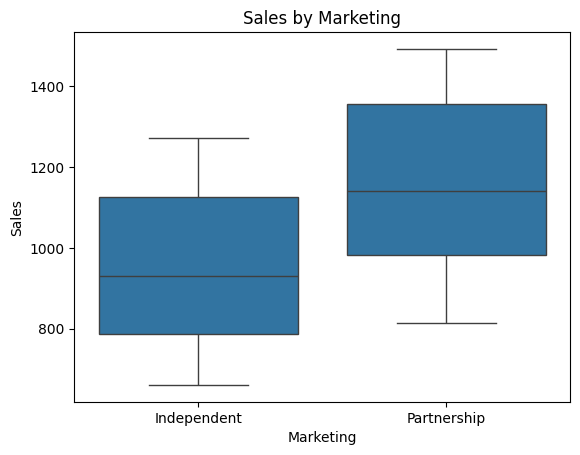

In [19]:
## Calculate Summary Statistics for the Main Effects ##

import seaborn as sns
import matplotlib.pyplot as plt

## Location Effect ##

location_effect = sales.groupby('Location')['Sales'].agg(['mean','std']).reset_index()

print(location_effect)

## Timing Effect ##

timing_effect = sales.groupby('Timing')['Sales'].agg(['mean','std']).reset_index()

print(timing_effect)

## Marketing Effect ##

marketing_effect = sales.groupby('Marketing')['Sales'].agg(['mean','std']).reset_index()

print(marketing_effect)

## Plot Boxplots for Each Factor using seaborn ##

## Location Boxplot ##

sns.boxplot(x='Location', y='Sales', data=sales)
plt.title('Sales by Location')
plt.show()

## Timing Boxplot ##

sns.boxplot(x='Timing', y='Sales', data=sales)
plt.title('Sales by Timing')
plt.show()

## Marketing Boxplot ##
sns.boxplot(x='Marketing', y='Sales', data=sales)
plt.title('Sales by Marketing')
plt.show()

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

In [ ]:
## Question 8 Code ##

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

In [ ]:
## Question 9 Code ##

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 12 Code ##

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

3. What is the difference between a fixed effect and a random effect?

4. What is the most important thing you learned in this class?